In [5]:
import json
import time
import numpy as np
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

M: 190 cykli | F: 235 cykli | features: 78


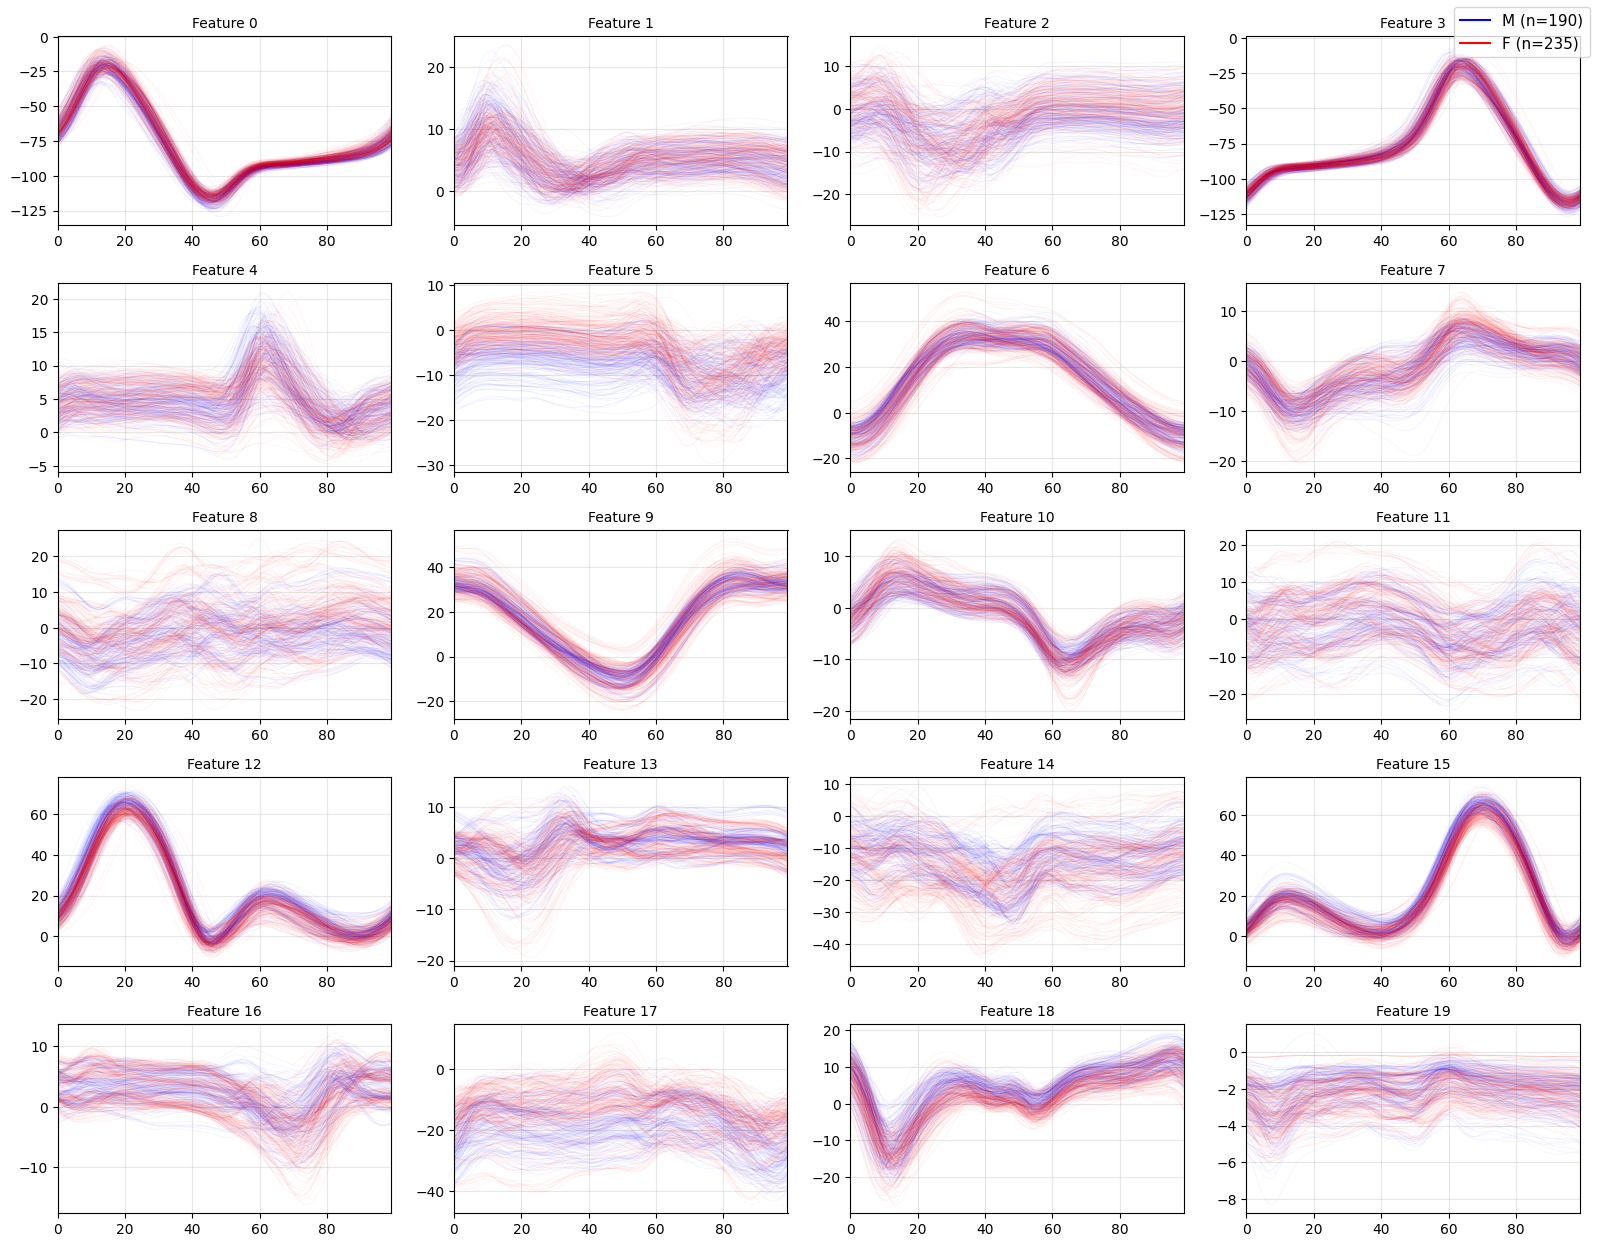

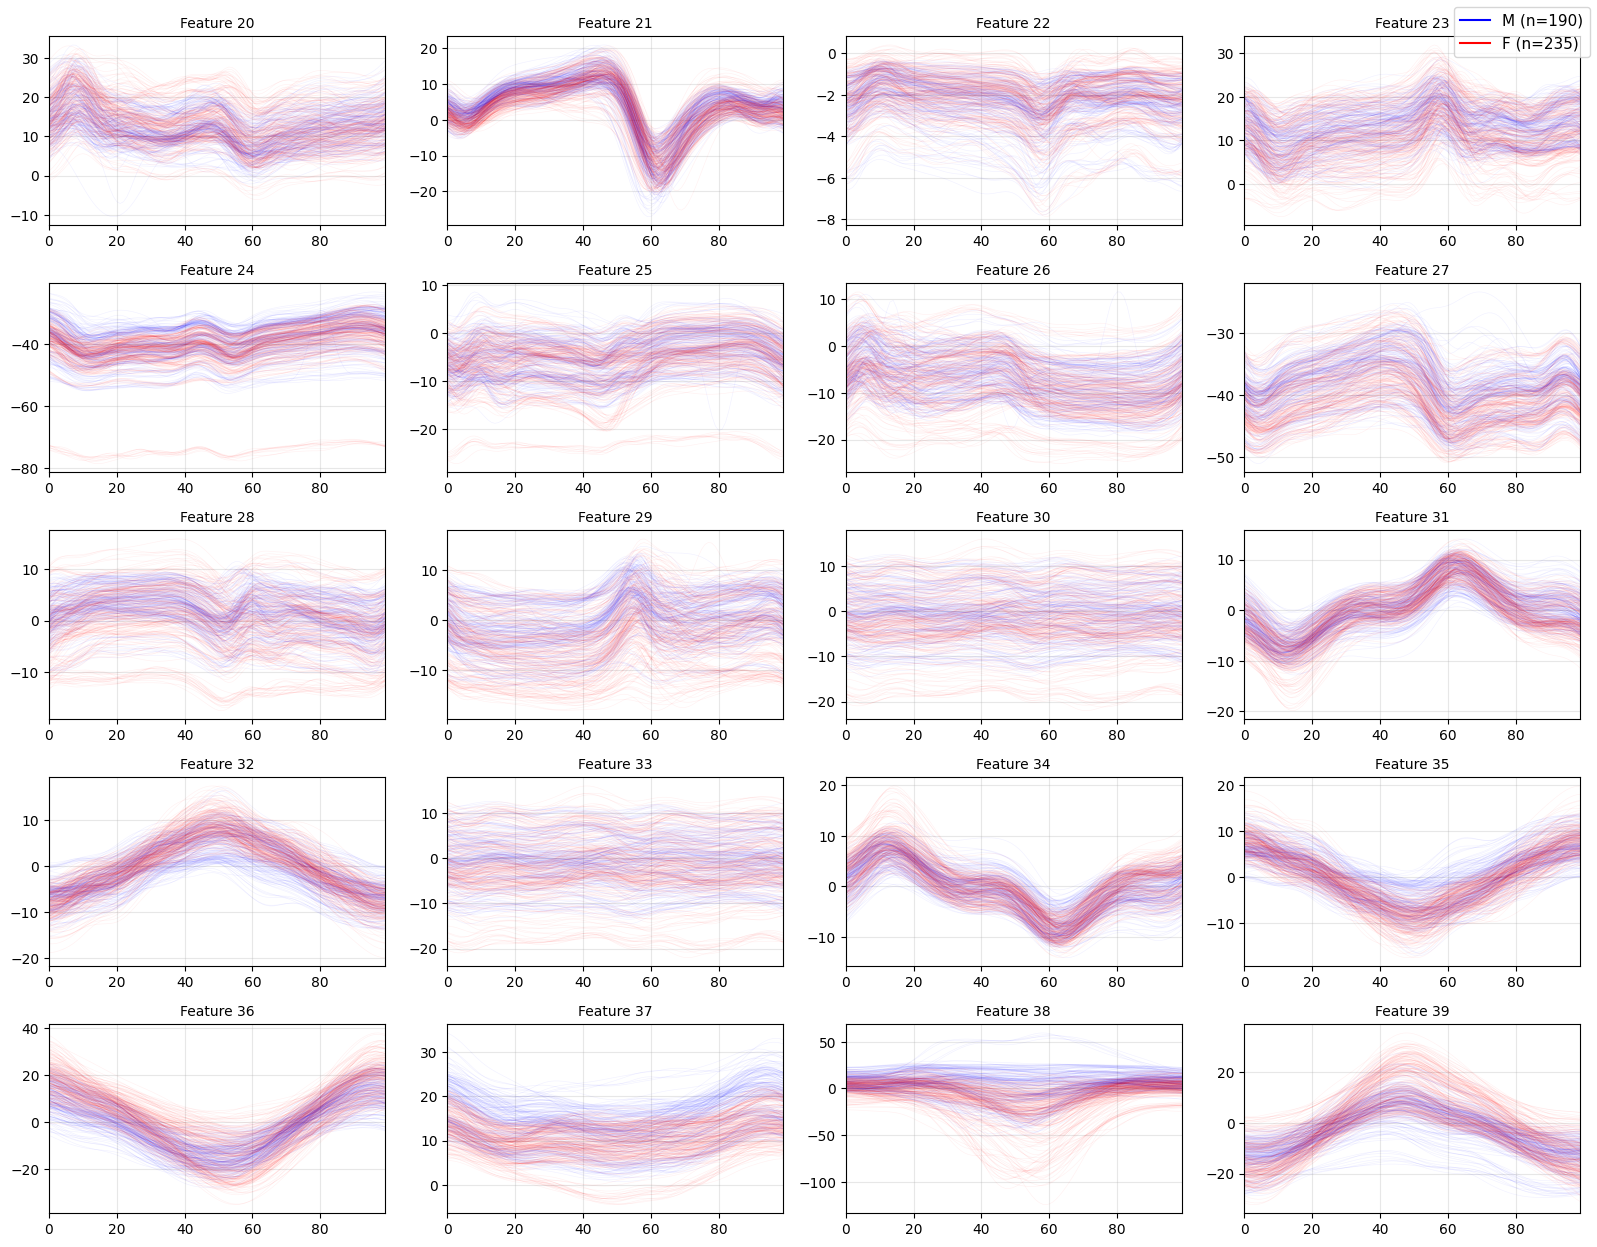

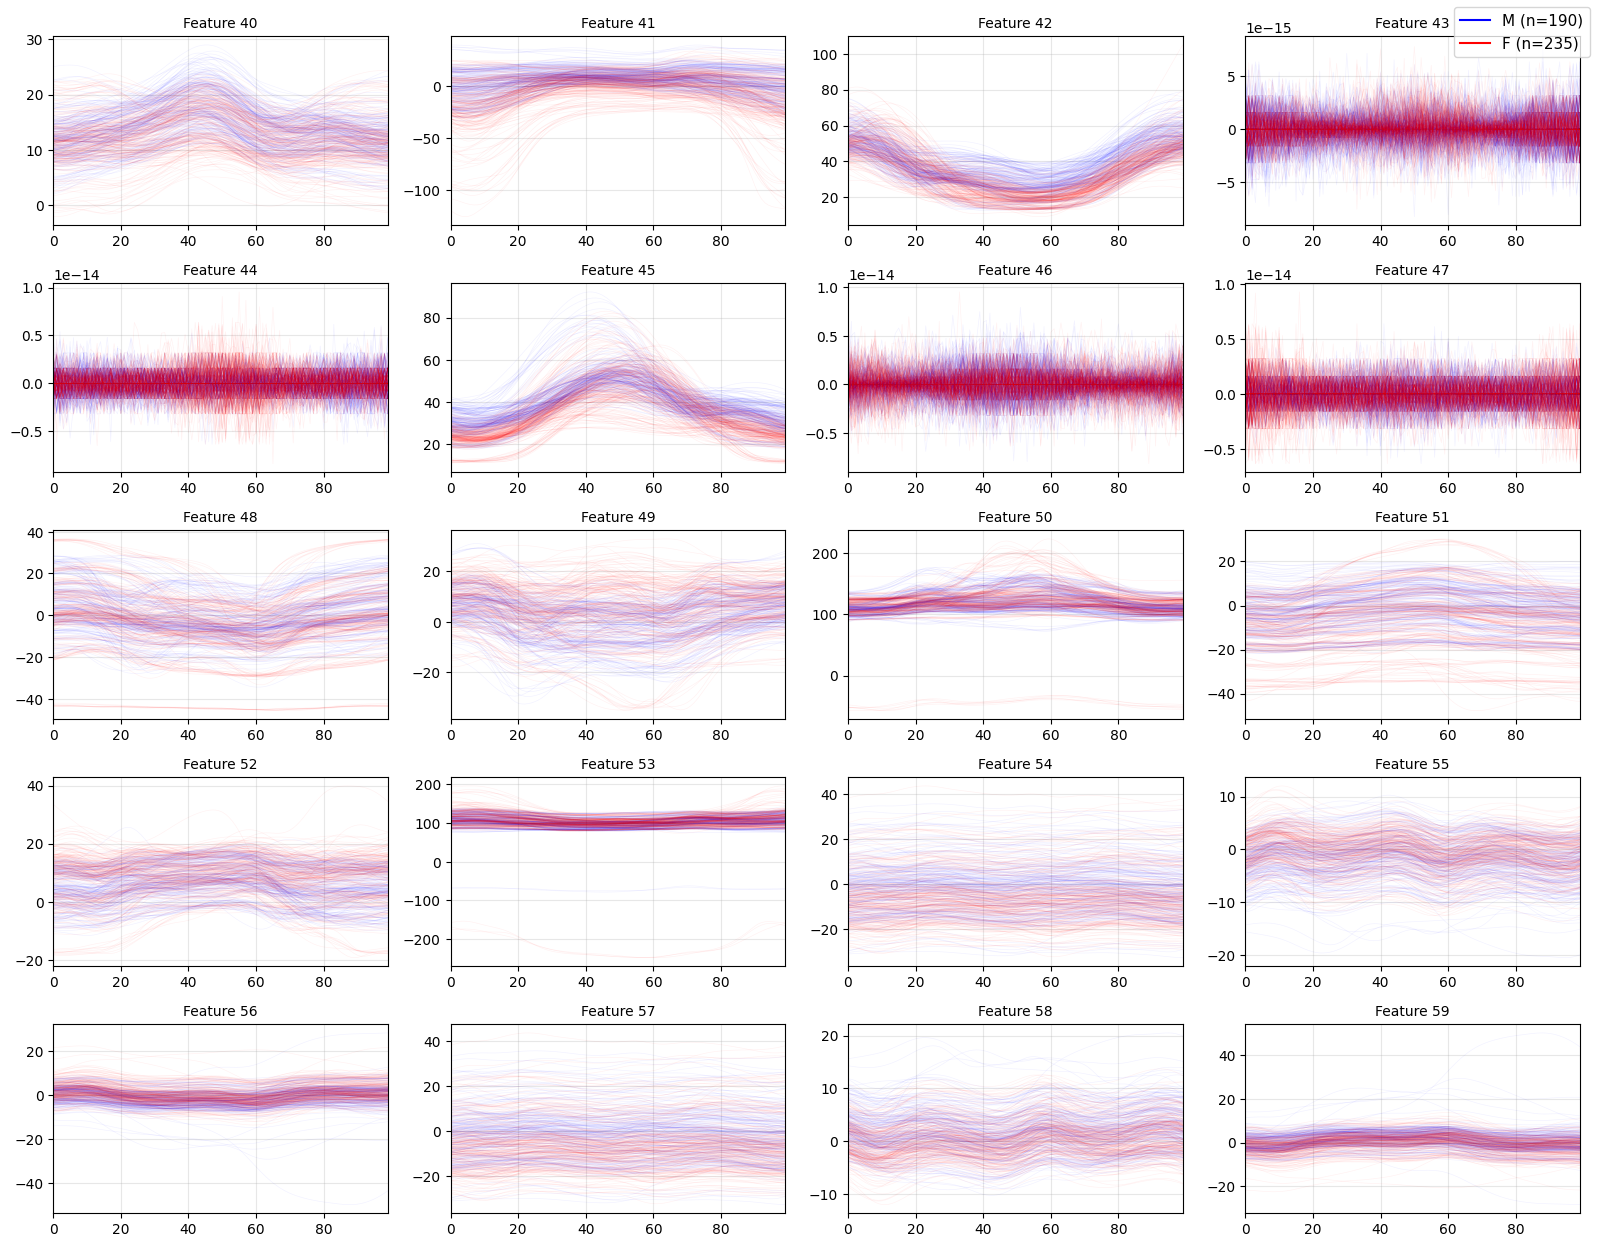

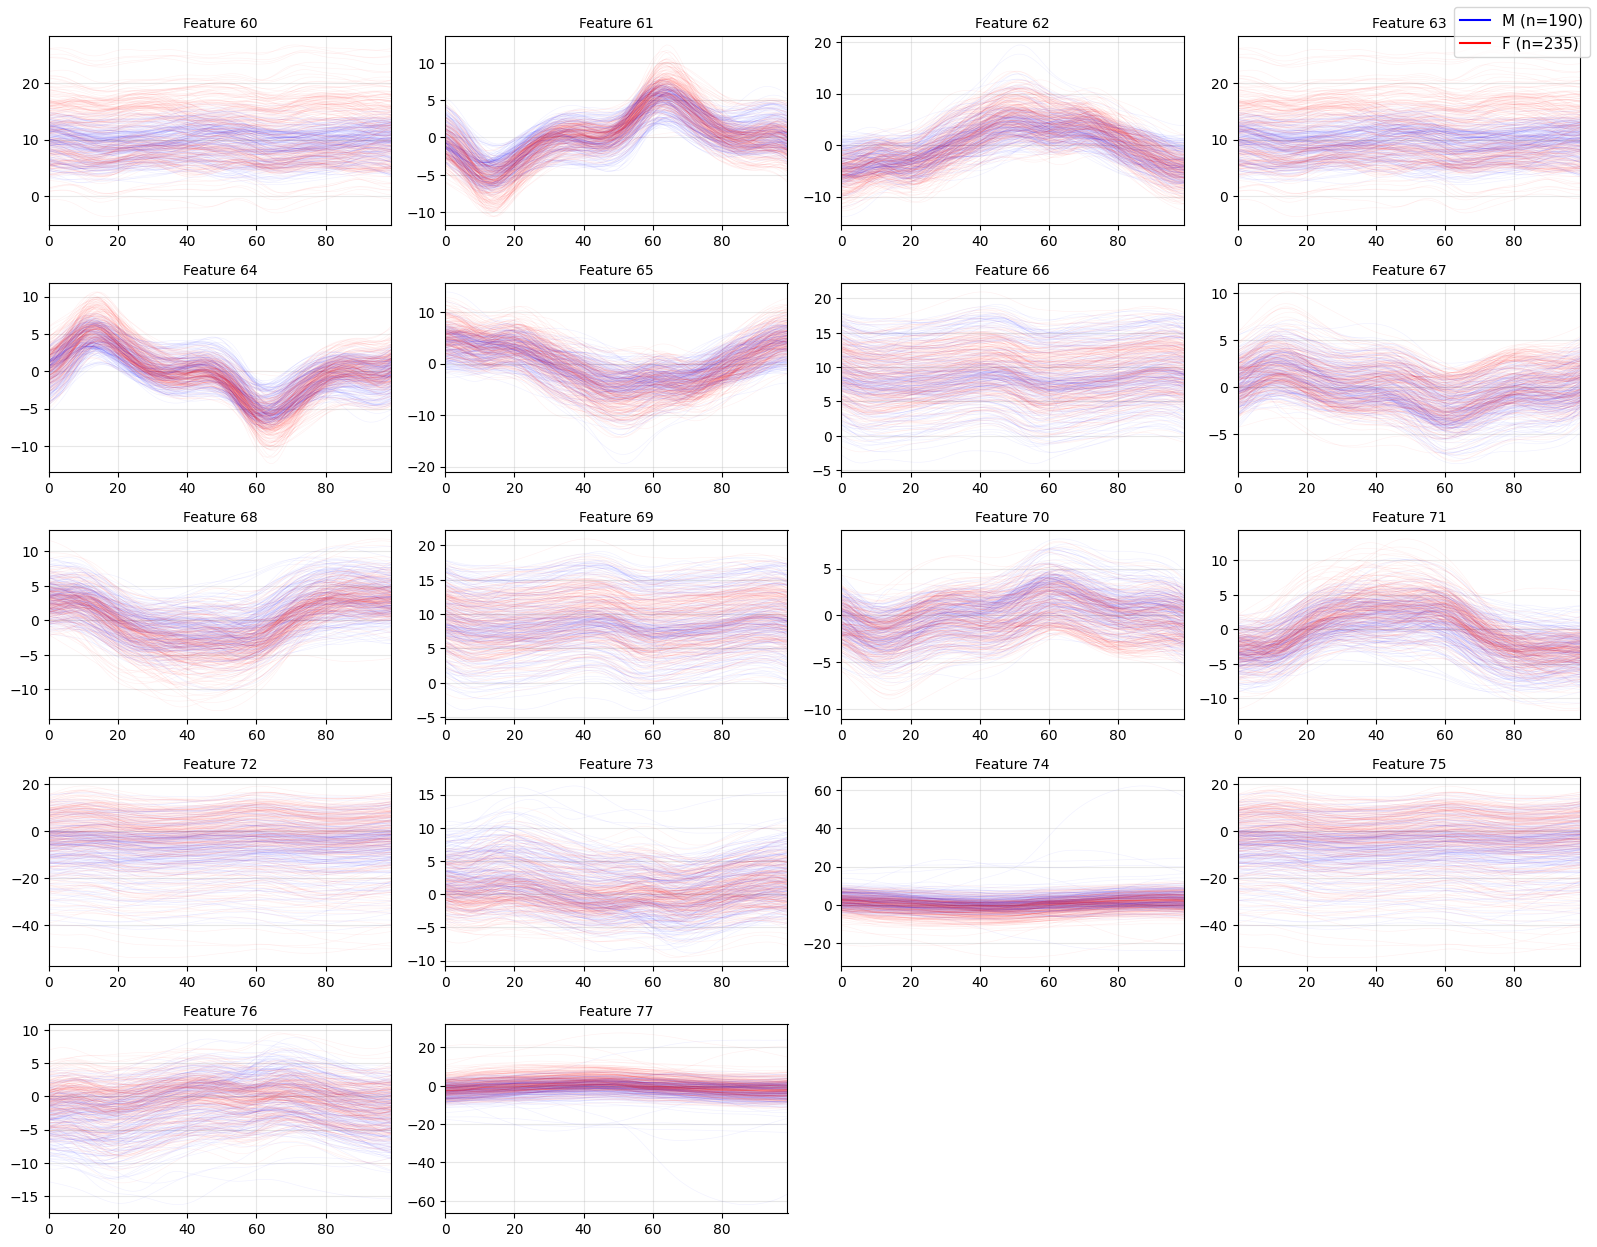

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path(r"E:\marcel.furs\Documents\Data_Run_Walk\Data_Run_Walk")
# === Load wszystkie cykle ===
ROOT_Exp = "exp1a_train_M_detect_F"
EXP_DIR  = ROOT / "EXPERIMENTS" / ROOT_Exp

X_tr = np.load(EXP_DIR / "X_train.npy")
X_va = np.load(EXP_DIR / "X_val.npy")
X_tn = np.load(EXP_DIR / "X_test_normal.npy")
X_ta = np.load(EXP_DIR / "X_test_anomaly.npy")

X_M = np.concatenate([X_tr, X_va, X_tn])   # wszystkie M cycles
X_F = X_ta                                  # wszystkie F cycles

if X_M.ndim == 2:
    X_M = X_M.reshape(-1, 100, 78)
    X_F = X_F.reshape(-1, 100, 78)
elif X_M.ndim == 4:
    X_M = X_M.reshape(X_M.shape[0], 100, -1)
    X_F = X_F.reshape(X_F.shape[0], 100, -1)

print(f"M: {X_M.shape[0]} cykli | F: {X_F.shape[0]} cykli | features: {X_M.shape[2]}")


# === Funkcja do plotowania spaghetti dla zadanego zakresu features ===
def plot_cycles_range(feat_start, feat_end, n_cols=4):
    """Spaghetti wszystkich M (niebieskie) i F (czerwone) dla features od feat_start do feat_end."""
    feats = list(range(feat_start, min(feat_end, X_M.shape[2])))
    n = len(feats)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2.5))
    axes = np.atleast_2d(axes).flatten()
    
    for i, feat in enumerate(feats):
        ax = axes[i]
        for cycle in X_M:
            ax.plot(cycle[:, feat], color='blue', alpha=0.05, linewidth=0.5)
        for cycle in X_F:
            ax.plot(cycle[:, feat], color='red',  alpha=0.05, linewidth=0.5)
        ax.set_title(f'Feature {feat}', fontsize=10)
        ax.set_xlim(0, 99)
        ax.grid(alpha=0.3)
    
    # ukryj nieużywane subploty
    for j in range(n, len(axes)):
        axes[j].axis('off')
    
    # ręczna legenda
    from matplotlib.lines import Line2D
    fig.legend(handles=[Line2D([0],[0], color='blue', label=f'M (n={len(X_M)})'),
                        Line2D([0],[0], color='red',  label=f'F (n={len(X_F)})')],
               loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()


# === Plot wszystkich 78 features w 4 stronach (po ~20 features na stronę) ===
plot_cycles_range(0, 20)
plot_cycles_range(20, 40)
plot_cycles_range(40, 60)
plot_cycles_range(60, 78)

In [7]:
import json
import pandas as pd

# Połącz oba pliki
all_rows = []
for path in ["results_v2.json", "all_results.json"]:
    try:
        with open(path) as f:
            data = json.load(f)
        for r in data:
            all_rows.append({
                "experiment": r["experiment"],
                "direction":  r["direction"],
                "config":     r.get("config") or "-",
                "model":      r["model"],
                "auc":        f"{r['auc_mean']:.3f} ± {r['auc_std']:.3f}",
                "ap":         f"{r['ap_mean']:.3f} ± {r['ap_std']:.3f}",
                "n_splits":   r["n_splits"],
                "hp":         str(r.get("hyperparameters", "n/a"))[:80],
            })
        print(f"Loaded {len(data)} rows from {path}")
    except FileNotFoundError:
        print(f"Skipped (not found): {path}")

df = pd.DataFrame(all_rows).sort_values(["experiment", "direction", "model", "config"])
print("\n", df.to_string(index=False))

Loaded 27 rows from results_v2.json
Loaded 15 rows from all_results.json

 experiment    direction config     model           auc            ap  n_splits                                                                               hp
       sex       F_to_M     AA        IF 0.650 ± 0.054 0.708 ± 0.041        30            {'n_estimators': 100, 'contamination': 'auto', 'max_samples': 'auto'}
       sex       F_to_M      A  LSTM_VAE 0.666 ± 0.039 0.708 ± 0.027        30 {'hidden_dim': 64, 'latent_dim': 4, 'dropout': 0.2, 'beta_kl': 0.01, 'batch_size
       sex       F_to_M      -    OC_SVM 0.652 ± 0.023 0.701 ± 0.018        30                                   {'kernel': 'rbf', 'gamma': 'scale', 'nu': 0.5}
       sex       F_to_M      A       PCA 0.741 ± 0.029 0.750 ± 0.023        30                                                              {'n_components': 4}
       sex       F_to_M     AA       PCA 0.659 ± 0.025 0.704 ± 0.018        30                                               